# LSTM Model for ETA Prediction
This notebook will be used to train and validate the LSTM model for predicting delivery ETAs and risk scores.

### .nc data verification

In [ ]:
import xarray as xr

filepath=r"D:\Copernicus_data\cmems_mod_glo_phy_my_0.083deg_P1D-m_1776686378510.nc"
ds = xr.open_dataset(filepath)

print("--"*75)
print("Coordinates",ds.coords)
print("--"*75)

print("Variables",ds.variables)
print("---"*75)

print("Variables Keys",ds.variables.keys())
print("---"*75)

print("Data variables",ds.data_vars)
print("---"*75)


------------------------------------------------------------------------------------------------------------------------------------------------------
Coordinates Coordinates:
  * time       (time) datetime64[ns] 240B 2024-01-01 2024-01-02 ... 2024-01-30
  * latitude   (latitude) float32 3kB 4.417 4.5 4.583 4.667 ... 66.92 67.0 67.08
  * longitude  (longitude) float32 4kB -75.42 -75.33 -75.25 ... 5.75 5.833 5.917
  * depth      (depth) float32 4B 0.494
------------------------------------------------------------------------------------------------------------------------------------------------------
Variables Frozen({'bottomT': <xarray.Variable (time: 30, latitude: 753, longitude: 977)> Size: 88MB
[22070430 values with dtype=float32]
Attributes:
    units:          degrees_C
    standard_name:  sea_water_potential_temperature_at_sea_floor
    long_name:      Sea floor potential temperature
    cell_methods:   area: mean
    unit_long:      Degrees Celsius
    valid_max:      36.60033


In [ ]:
print("--"*75)
print("Coordinates",ds.coords)
print("--"*75)

print("Coordinates Keys",ds.coords.keys())
print("--"*75)

print("Dimensions",ds.dims)
print("--"*75)

------------------------------------------------------------------------------------------------------------------------------------------------------
Coordinates Coordinates:
  * time       (time) datetime64[ns] 240B 2024-01-01 2024-01-02 ... 2024-01-30
  * latitude   (latitude) float32 3kB 4.417 4.5 4.583 4.667 ... 66.92 67.0 67.08
  * longitude  (longitude) float32 4kB -75.42 -75.33 -75.25 ... 5.75 5.833 5.917
  * depth      (depth) float32 4B 0.494
------------------------------------------------------------------------------------------------------------------------------------------------------
Coordinates Keys KeysView(Coordinates:
  * time       (time) datetime64[ns] 240B 2024-01-01 2024-01-02 ... 2024-01-30
  * latitude   (latitude) float32 3kB 4.417 4.5 4.583 4.667 ... 66.92 67.0 67.08
  * longitude  (longitude) float32 4kB -75.42 -75.33 -75.25 ... 5.75 5.833 5.917
  * depth      (depth) float32 4B 0.494)
-----------------------------------------------------------------------

In [ ]:
print("--"*75)
print("Attributes",ds.attrs)
print("--"*75)

print("Time",ds.time.values)
print("--"*75)

print("Latitude",ds.latitude.values)
print("--"*75)

print("Longitude",ds.longitude.values)
print("--"*75)

------------------------------------------------------------------------------------------------------------------------------------------------------
Attributes {'Conventions': 'CF-1.11', 'title': 'daily mean fields from Global Ocean Physics Analysis and Forecast updated Daily', 'institution': 'MERCATOR OCEAN', 'source': 'MERCATOR GLORYS12V1', 'history': '2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation', 'references': 'http://www.mercator-ocean.fr', 'comment': 'CMEMS product', 'subset:source': 'ARCO data downloaded from the Marine Data Store using the MyOcean Data Portal', 'subset:productId': 'GLOBAL_MULTIYEAR_PHY_001_030', 'subset:datasetId': 'cmems_mod_glo_phy_my_0.083deg_P1D-m_202311', 'subset:date': '2026-04-20T11:59:38.510Z'}
------------------------------------------------------------------------------------------------------------------------------------------------------
Time ['2024-01-01T00:00:00.000000000' '2024-01-02T00:00:00.000000000'
 '2024-01-03T00:00:00.000000000' '

In [ ]:
print("--"*75)
print("Depth",ds.depth.values)
print("--"*75)

print("Bottom temperature",ds.bottomT.values)
print("--"*75)

print("Salinity",ds.so.values)
print("--"*75)

------------------------------------------------------------------------------------------------------------------------------------------------------
Depth [0.494025]
------------------------------------------------------------------------------------------------------------------------------------------------------
Bottom temperature [[[        nan         nan         nan ... 31.32673    30.604542
           nan]
  [        nan         nan         nan ... 30.600147           nan
           nan]
  [        nan         nan         nan ...         nan         nan
           nan]
  ...
  [-1.738731   -1.7394634  -1.7401959  ... -0.7096469  -0.7316202
   -0.73455   ]
  [-1.7365336  -1.7365336  -1.7365336  ... -0.73747975 -0.7455366
   -0.7565233 ]
  [-1.7409284  -1.738731   -1.7379986  ... -0.8561357  -0.8158513
   -0.79534286]]

 [[        nan         nan         nan ... 30.614796   30.542284
           nan]
  [        nan         nan         nan ... 30.543749           nan
           na

## **Successfully Achieved by far**

We have successfully completed the Temporal & Spatial Fusion phase.

* Step 1 (Done): Parsed raw AIS Parquet files.

* Step 2 (Done): Aligned 4D Copernicus Physics (Currents, Height) with 2D Ship GPS points.

* Step 3 (Done): Fused these into a unified training-ready Parquet format for all 12 months of 2024.

Check ais_metadata_extractor.py and temporal_fusion.py script

In [17]:
import polars as pl

# CHANGE: Load from the FUSED directory, not the raw directory
df = pl.read_parquet(r"D:\AIS_data\fused_training_data_2024\fused_ais_physics_2024_01.parquet")

# Check for NaNs and also check the range of values
diagnostics = df.select([
    pl.col("uo").is_null().sum().alias("uo_nulls"),
    pl.col("vo").is_null().sum().alias("vo_nulls"),
    pl.col("uo").mean().alias("avg_east_current"),
    pl.col("vo").mean().alias("avg_north_current"),
    pl.count().alias("total_rows")
])

print(diagnostics)

# Let's see a sample of the new columns
print(df.select(["mmsi", "cell_ll_lat", "cell_ll_lon", "uo", "vo", "zos"]).head(5))

shape: (1, 5)
┌──────────┬──────────┬──────────────────┬───────────────────┬────────────┐
│ uo_nulls ┆ vo_nulls ┆ avg_east_current ┆ avg_north_current ┆ total_rows │
│ ---      ┆ ---      ┆ ---              ┆ ---               ┆ ---        │
│ u32      ┆ u32      ┆ f32              ┆ f32               ┆ u32        │
╞══════════╪══════════╪══════════════════╪═══════════════════╪════════════╡
│ 0        ┆ 0        ┆ NaN              ┆ NaN               ┆ 802406     │
└──────────┴──────────┴──────────────────┴───────────────────┴────────────┘
shape: (5, 6)
┌───────────┬─────────────┬─────────────┬──────────┬──────────┬──────────┐
│ mmsi      ┆ cell_ll_lat ┆ cell_ll_lon ┆ uo       ┆ vo       ┆ zos      │
│ ---       ┆ ---         ┆ ---         ┆ ---      ┆ ---      ┆ ---      │
│ i64       ┆ f64         ┆ f64         ┆ f32      ┆ f32      ┆ f32      │
╞═══════════╪═════════════╪═════════════╪══════════╪══════════╪══════════╡
│ 224029760 ┆ -3.6        ┆ -15.5       ┆ 0.054323 ┆ 0.025636 ┆ 0

C:\Users\DEEPMALYA\AppData\Local\Temp\ipykernel_38448\2323680333.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("total_rows")


#### Investigation stage to check if our data has the SOG/COG data Speed Over Ground, Course Over Ground 

In [18]:
print("--- Column Names ---")
print(df.columns)

print("\n--- Value Ranges (Check for Speed/Course) ---")
# We look for columns containing 'speed', 'sog', 'course', or 'cog' (case-insensitive)
potential_cols = [c for c in df.columns if any(x in c.lower() for x in ['speed', 'sog', 'course', 'cog'])]
if potential_cols:
    print(df.select(potential_cols).describe())
else:
    print("No obvious Speed/Course columns found. We may need to derive them from Lat/Lon over time.")

--- Column Names ---
['date', 'cell_ll_lat', 'cell_ll_lon', 'mmsi', 'hours', 'fishing_hours', 'vessel_class_gfw', 'length_m_gfw', 'engine_power_kw_gfw', 'tonnage_gt_gfw', 'uo', 'vo', 'zos']

--- Value Ranges (Check for Speed/Course) ---
No obvious Speed/Course columns found. We may need to derive them from Lat/Lon over time.


### Feature Engineering

Regardless of whether we have SOG/COG yet, we need to prepare our physics features. We are going to calculate Magnitude and Heading.

In oceanography and navigation:

* Magnitude: How strong is the current? ($m/s$)
* Direction: Which way is it pointing? (Degrees from North)

1. Vector Magnitude & Direction: 
We need to know the actual speed of the water and where it's pushing.
* Current Speed: $Velocity_{water} = \sqrt{uo^2 + vo^2}$
* Current Angle: Using arctan2(vo, uo) to see the heading of the water.

In [ ]:
"""Sample for 1 parquet file"""

import numpy as np

def engineer_features(file_path, output_path):
    df = pl.read_parquet(file_path)
    
    # 1. Fill NaNs in Physics Columns
    # We use forward fill/backward fill per MMSI so we don't 'leak' data between different ships
    df = df.sort(["mmsi", "date"])
    df = df.with_columns([
        pl.col("uo").fill_nan(None).forward_fill().backward_fill().over("mmsi"),
        pl.col("vo").fill_nan(None).forward_fill().backward_fill().over("mmsi"),
        pl.col("zos").fill_nan(None).forward_fill().backward_fill().over("mmsi")
    ])

    # 2. Vector Math: Magnitude and Heading
    # Current Speed = sqrt(uo^2 + vo^2)
    # Current Direction = arctan2(uo, vo) converted to degrees
    df = df.with_columns([
        ((pl.col("uo")**2 + pl.col("vo")**2)**0.5).alias("current_speed_ms"),
        (pl.arctan2d(pl.col("uo"), pl.col("vo"))).alias("current_direction_deg")
    ])
    
    # 3. Clean up Direction (Map -180/180 to 0/360)
    df = df.with_columns(
        pl.when(pl.col("current_direction_deg") < 0)
        .then(pl.col("current_direction_deg") + 360)
        .otherwise(pl.col("current_direction_deg"))
        .alias("current_direction_360")
    )

    # 4. Final Polish: Drop any remaining rows that are still NaN 
    # (Only happens if an entire ship's path is over land)
    df = df.drop_nulls(subset=["uo", "vo"])

    df.write_parquet(output_path)
    print(f"Feature Engineering Complete: {output_path}")
    return df

# Run it for Month 1
input_file = r"D:\AIS_data\fused_training_data_2024\fused_ais_physics_2024_01.parquet"
output_file = r"D:\AIS_data\fused_training_data_2024\enriched_ais_2024_01.parquet"
enriched_df = engineer_features(input_file, output_file)

# Check the new averages!
print("\nNew Clean Averages:")
print(enriched_df.select([
    pl.col("current_speed_ms").mean().alias("avg_speed"),
    pl.col("current_direction_360").mean().alias("avg_direction")
]))

C:\Users\DEEPMALYA\AppData\Local\Temp\ipykernel_8332\3118729031.py:20: DeprecationWarning: `arctan2d` is deprecated; use `arctan2` followed by `.degrees()` instead.
  (pl.arctan2d(pl.col("uo"), pl.col("vo"))).alias("current_direction_deg")


Feature Engineering Complete: D:\AIS_data\fused_training_data_2024\enriched_ais_2024_01.parquet

New Clean Averages:
shape: (1, 2)
┌───────────┬───────────────┐
│ avg_speed ┆ avg_direction │
│ ---       ┆ ---           │
│ f32       ┆ f32           │
╞═══════════╪═══════════════╡
│ 0.136132  ┆ 172.570206    │
└───────────┴───────────────┘


Since we don’t have SOG (Speed Over Ground) or COG (Course Over Ground) in the dataset, the next step is actually a fundamental part of maritime data science: Reconstructing Vessel Kinematics.

Without these columns, we only know where the ship was at a certain time. We don't know how fast it was going or which way it was pointing. We have to calculate this by measuring the distance and bearing between consecutive GPS pings.

 **The "Great Circle" Calculation** - The Logic

Because the Earth is a sphere, we can't use simple Pythagorean geometry for long distances. We use the Haversine Formula to calculate the distance between two pings and the Forward Bearing formula for the course.

## **MasterPlan**

* Calculate Ship Velocity: Derive speed and heading from lat/lon and date.

* Calculate Ocean Impact: Use the uo/vo we fused earlier to find the current's speed and direction.

* Calculate Drift/Interaction: Find the difference between the ship's course and the water's flow.

* Batch Process: Wrap this in a loop that handles all 12 Parquet files automatically.

In [ ]:
import polars as pl
import numpy as np
import os
from glob import glob

def process_all_features(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    files = sorted(glob(os.path.join(input_dir, "fused_ais_physics_2024_*.parquet")))

    for file_path in files:
        month_str = os.path.basename(file_path).split("_")[-1]
        print(f"--- Engineering Features for Month {month_str} ---")
        
        # FIX: Explicitly cast 'date' to datetime immediately after loading
        df = (
            pl.read_parquet(file_path)
            .with_columns(pl.col("date").str.to_datetime()) # Convert strings to timestamps
            .sort(["mmsi", "date"])
        )

        # 1. TEMPORAL & SPATIAL DIFFS (Per Ship)
        df = df.with_columns([
            pl.col("date").diff().dt.total_seconds().over("mmsi").alias("delta_t"),
            pl.col("cell_ll_lat").shift().over("mmsi").alias("prev_lat"),
            pl.col("cell_ll_lon").shift().over("mmsi").alias("prev_lon")
        ])

        # 2. CALCULATE VESSEL SPEED (Approximate)
        # We ensure floats are used to prevent any more 'str' logic errors
        df = df.with_columns([
            (((pl.col("cell_ll_lat") - pl.col("prev_lat")).cast(pl.Float64)**2 + 
              (pl.col("cell_ll_lon") - pl.col("prev_lon")).cast(pl.Float64)**2)**0.5 * 111111).alias("dist_m")
        ])
        
        df = df.with_columns([
            (pl.col("dist_m") / pl.col("delta_t")).alias("vessel_sog_ms")
        ])

        # 3. OCEAN PHYSICS CALCULATIONS
        df = df.with_columns([
            ((pl.col("uo")**2 + pl.col("vo")**2)**0.5).alias("current_speed_ms"),
            (pl.arctan2d(pl.col("uo"), pl.col("vo"))).alias("current_dir_deg")
        ])

        # 4. CLEANING
        # Drop first rows of each ship (where delta_t/prev_lat are null) 
        # and points hitting land (uo/vo are NaN)
        df = df.drop_nulls(subset=["uo", "vo", "vessel_sog_ms", "delta_t"])
        
        # Filter out static ships (speed ~ 0) and teleporting ships (speed > 25m/s)
        # And ensure delta_t isn't zero to avoid division by zero
        df = df.filter((pl.col("delta_t") > 0) & (pl.col("vessel_sog_ms") > 0.1) & (pl.col("vessel_sog_ms") < 25))

        # 5. SAVE ENRICHED DATA
        # Adding .parquet extension back if it got stripped in output naming
        final_filename = f"final_enriched_2024_{month_str}"
        if not final_filename.endswith(".parquet"):
            final_filename += ".parquet"
            

        output_path = os.path.join(output_dir, final_filename)
        df.write_parquet(output_path)
        print(f"Saved: {output_path} | Rows: {len(df)}")

# --- CONFIG ---
fused_dir = r"D:\AIS_data\fused_training_data_2024"
final_dir = r"D:\AIS_data\final_model_ready_2024"

if __name__ == "__main__":
    process_all_features(fused_dir, final_dir)

--- Engineering Features for Month 01.parquet ---


C:\Users\DEEPMALYA\AppData\Local\Temp\ipykernel_8332\2595764360.py:42: DeprecationWarning: `arctan2d` is deprecated; use `arctan2` followed by `.degrees()` instead.
  (pl.arctan2d(pl.col("uo"), pl.col("vo"))).alias("current_dir_deg")


Saved: D:\AIS_data\final_model_ready_2024\final_enriched_2024_01.parquet | Rows: 63827
--- Engineering Features for Month 02.parquet ---
Saved: D:\AIS_data\final_model_ready_2024\final_enriched_2024_02.parquet | Rows: 61894
--- Engineering Features for Month 03.parquet ---
Saved: D:\AIS_data\final_model_ready_2024\final_enriched_2024_03.parquet | Rows: 69424
--- Engineering Features for Month 04.parquet ---
Saved: D:\AIS_data\final_model_ready_2024\final_enriched_2024_04.parquet | Rows: 80960
--- Engineering Features for Month 05.parquet ---
Saved: D:\AIS_data\final_model_ready_2024\final_enriched_2024_05.parquet | Rows: 91672
--- Engineering Features for Month 06.parquet ---
Saved: D:\AIS_data\final_model_ready_2024\final_enriched_2024_06.parquet | Rows: 88287
--- Engineering Features for Month 07.parquet ---
Saved: D:\AIS_data\final_model_ready_2024\final_enriched_2024_07.parquet | Rows: 91492
--- Engineering Features for Month 08.parquet ---
Saved: D:\AIS_data\final_model_ready_2024

In [ ]:
ds=pl.read_parquet(r"D:\AIS_data\final_model_ready_2024\final_enriched_2024_12.parquet")
ds.head()

date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours,vessel_class_gfw,length_m_gfw,engine_power_kw_gfw,tonnage_gt_gfw,uo,vo,zos,delta_t,prev_lat,prev_lon,dist_m,vessel_sog_ms,current_speed_ms,current_dir_deg
datetime[μs],f64,f64,i64,f64,f64,str,f64,f64,f64,f32,f32,f32,i64,f64,f64,f64,f64,f32,f32
2024-12-02 00:00:00,31.5,-10.0,9125218,0.8475,0.0,"""drifting_longlines""",15.666,163.061,32.174,0.018921,0.110477,-0.102847,86400,31.5,-10.6,66666.6,0.771604,0.112086,9.718792
2024-12-03 00:00:00,31.5,-9.8,9125218,0.5491,0.0,"""drifting_longlines""",15.666,163.061,32.174,-0.059206,-0.187384,-0.111698,86400,31.4,-10.6,89580.552067,1.036812,0.196515,-162.4655
2024-12-18 00:00:00,32.0,-10.5,9125218,0.4494,0.1986,"""drifting_longlines""",15.666,163.061,32.174,0.042726,-0.042726,-0.14008,86400,31.6,-9.9,80123.281554,0.927353,0.060424,135.0
2024-12-19 00:00:00,31.8,-10.1,9125218,0.5836,0.0,"""drifting_longlines""",15.666,163.061,32.174,-0.140385,-0.194098,-0.147404,86400,32.0,-10.7,70272.76662,0.813342,0.239545,-144.122894
2024-12-24 00:00:00,32.1,-10.5,9125218,1.9263,1.9263,"""drifting_longlines""",15.666,163.061,32.174,-0.010376,0.006104,-0.139775,432000,31.7,-10.0,71145.753715,0.164689,0.012038,-59.534458


### Data Preparation for LSTM model traininig

We can't just throw raw coordinates and timestamps into a Neural Network. We need to handle two things: Normalization and Temporal Sequencing.

In [12]:
final_dir = r"D:\AIS_data\final_model_ready_2024"
files = glob(os.path.join(final_dir, "*.parquet"))

# Features we want to scale for the model
features_to_scale = [
    "cell_ll_lat", "cell_ll_lon", "vessel_sog_ms", 
    "uo", "vo", "zos", "current_speed_ms", 
    "engine_power_kw_gfw", "tonnage_gt_gfw"
]

# We will read all files and calculate min/max/mean/std
# This might be memory intensive, so we do it lazily
full_scan = pl.scan_parquet(files)

stats = full_scan.select([
    *[pl.col(c).mean().alias(f"{c}_mean") for c in features_to_scale],
    *[pl.col(c).std().alias(f"{c}_std") for c in features_to_scale]
]).collect()

print("--- Global Statistics for Scaling ---")
print(stats)

--- Global Statistics for Scaling ---
shape: (1, 18)
┌────────────┬────────────┬────────────┬─────────┬───┬─────────┬───────────┬───────────┬───────────┐
│ cell_ll_la ┆ cell_ll_lo ┆ vessel_sog ┆ uo_mean ┆ … ┆ zos_std ┆ current_s ┆ engine_po ┆ tonnage_g │
│ t_mean     ┆ n_mean     ┆ _ms_mean   ┆ ---     ┆   ┆ ---     ┆ peed_ms_s ┆ wer_kw_gf ┆ t_gfw_std │
│ ---        ┆ ---        ┆ ---        ┆ f32     ┆   ┆ f32     ┆ td        ┆ w_std     ┆ ---       │
│ f64        ┆ f64        ┆ f64        ┆         ┆   ┆         ┆ ---       ┆ ---       ┆ f64       │
│            ┆            ┆            ┆         ┆   ┆         ┆ f32       ┆ f64       ┆           │
╞════════════╪════════════╪════════════╪═════════╪═══╪═════════╪═══════════╪═══════════╪═══════════╡
│ 43.824567  ┆ -13.866217 ┆ 0.793791   ┆ NaN     ┆ … ┆ NaN     ┆ NaN       ┆ 1131.9015 ┆ 869.62012 │
│            ┆            ┆            ┆         ┆   ┆         ┆           ┆ 2         ┆ 8         │
└────────────┴────────────┴───────────

### Extracting the statistics of the data

In [13]:
# Safe calculation ignoring NaNs to get our scaling factors
stats = full_scan.select([
    *[pl.col(c).filter(pl.col(c).is_not_nan()).mean().alias(f"{c}_mean") for c in features_to_scale],
    *[pl.col(c).filter(pl.col(c).is_not_nan()).std().alias(f"{c}_std") for c in features_to_scale]
]).collect()

# Convert to a dictionary for easy access during scaling
scaling_map = stats.to_dicts()[0]
print("Clean Stats Ready for Scaling!")

Clean Stats Ready for Scaling!


Neural Networks need tensors. 

We need to convert our Parquet files into sequences (e.g., look at the last 10 pings to predict the 11th).

**The Strategy:**
* **Standardize:** Subtract mean, divide by std using the scaling_map.
* **Sequence Generation:** Group by mmsi and create windows of size N=10.

### Scaling (Normalization)

Neural networks are sensitive to the magnitude of inputs. Our engine_power_kw feature in the data might be in the thousands, while uo is 0.05. If we don't scale them, the model will think the engine power is $100,000\times$ more important than the ocean current.

In [21]:
import polars as pl
import os
from glob import glob
import numpy as np

def scale_datasets(input_dir, output_dir, scaling_params):
    os.makedirs(output_dir, exist_ok=True)
    # Finding files: final_enriched_2024_01.parquet, etc.
    files = sorted(glob(os.path.join(input_dir, "final_enriched_2024_*.parquet")))
    
    features = [
        "cell_ll_lat", "cell_ll_lon", "vessel_sog_ms", 
        "uo", "vo", "zos", "current_speed_ms", 
        "engine_power_kw_gfw", "tonnage_gt_gfw"
    ]

    for file_path in files:
        # 1. Extract the month index from the old filename (e.g., '01' from '..._01.parquet')
        filename_raw = os.path.basename(file_path)
        month_part = filename_raw.split("_")[-1] # This gets '01.parquet'
        
        # 2. Define the new distinct filename
        new_filename = f"normalized_2024_{month_part}"
        output_file_path = os.path.join(output_dir, new_filename)

        # 3. Process Data
        df = pl.read_parquet(file_path).drop_nans(features).drop_nulls(features)
        
        for col in features:
            mean = scaling_params.get(f"{col}_mean", 0) 
            std = scaling_params.get(f"{col}_std", 1)
            
            # Safety check for zero/NaN standard deviation
            if std == 0 or np.isnan(std) or std is None: 
                std = 1.0
                
            df = df.with_columns(((pl.col(col) - mean) / std).alias(col))
        
        # 4. Final drop and Save
        df = df.drop_nans(features) 
        df.write_parquet(output_file_path)
        
        # Corrected print statement to show the NEW path
        print(f"Scaled and saved: {output_file_path}")

# --- EXECUTION ---
final_dir = r"D:\AIS_data\final_model_ready_2024"
scaled_dir = r"D:\AIS_data\scaled_model_input_2024"

# Ensure scaling_map is defined in your environment before running
scale_datasets(final_dir, scaled_dir, scaling_map)

Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_01.parquet
Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_02.parquet
Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_03.parquet
Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_04.parquet
Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_05.parquet
Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_06.parquet
Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_07.parquet
Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_08.parquet
Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_09.parquet
Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_10.parquet
Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_11.parquet
Scaled and saved: D:\AIS_data\scaled_model_input_2024\normalized_2024_12.parquet


### Flow to Follow 

* Raw Data $\rightarrow$ MaritimeDataset (Slices into windows)
* Windows $\rightarrow$ DataLoader (Groups into batches)
* Batches $\rightarrow$ PhysicsInformedLSTM (Produces Predictions)
* Predictions $\rightarrow$ custom_physics_loss (Calculates Error + Physics Penalty)
* Loss $\rightarrow$ Optimizer (Adjusts the "Brain" to be smarter next time)

## **Utils/ Helpers**
- Custom Data Preparation and Model Development

### **Windowing (Sliding Windows)**

Since we are likely predicting a trajectory, the model needs to see a "history" of the ship's path to predict the next point. This is called a sliding window.

* Input (X): The last 5 pings (Coordinates + Vessel Speed + Ocean Currents).

* Target (y): The next ping's coordinates or speed.

In [8]:
import polars as pl
import xarray as xa
import numpy as np
from glob import glob
from torch.utils.data import Dataset

In [26]:
class MaritimeDataset(torch.utils.data.Dataset):
    def __init__(self, df, window_size=10):
        # 1. Ensure data is sorted by ship (mmsi) and then time/date
        df = df.sort(["mmsi", "date", "hours"])
        
        self.window_size = window_size
        # Convert to numpy for faster indexing
        self.data = df.select([
            "cell_ll_lat", "cell_ll_lon", "vessel_sog_ms", 
            "uo", "vo", "zos"
        ]).to_numpy().astype(np.float32)
        
        self.mmsis = df.select("mmsi").to_numpy().flatten()
        
        # 2. Pre-filter valid indices
        # A start index is only valid if the ship at the start is the 
        # same as the ship at the end of the window (index + window_size)
        self.valid_indices = []
        for i in range(len(self.data) - window_size):
            if self.mmsis[i] == self.mmsis[i + window_size]:
                self.valid_indices = self.valid_indices + [i]
                
        print(f"Created {len(self.valid_indices)} valid contiguous sequences.")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start_idx = self.valid_indices[idx]
        
        # History (Window)
        seq = self.data[start_idx : start_idx + self.window_size]
        
        # Target: Delta (Difference between T+1 and T)
        # Ensure your target logic uses the same columns
        target = self.data[start_idx + self.window_size, :2] - self.data[start_idx + self.window_size - 1, :2]
        
        # Physics context: [last_lat, last_lon, uo, vo]
        physics_ctx = np.array([
            self.data[start_idx + self.window_size - 1, 0], # last_lat
            self.data[start_idx + self.window_size - 1, 1], # last_lon
            self.data[start_idx + self.window_size, 3],     # current uo
            self.data[start_idx + self.window_size, 4]      # current vo
        ], dtype=np.float32)
        
        return torch.tensor(seq), torch.tensor(target), torch.tensor(physics_ctx)

### **The LSTM architecture|**

A Physically Informed LSTM (PI-LSTM) fits the "Lattice" philosophy perfectly: instead of being a black box, our model will respect the laws of fluid dynamics. By incorporating the ocean currents ($uo, vo$) as physical constraints, the LSTM doesn't just "guess" where the ship goes; it understands the "drift" being applied to the hull

* Inputs: [Lat, Lon, SOG, Engine Power, Tonnage, uo, vo, zos]
* Physics Constraint: The change in $Lat/Lon$ ($\Delta Pos$) should roughly equal $(V_{vessel} + V_{ocean}) \times \Delta t$. If the model predicts a position that ignores the ocean's push, we penalize it during training.

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PhysicsInformedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2):
        super(PhysicsInformedLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        # Tanh constrains the 'delta' so the ship can't jump 200km in one step
        prediction = torch.tanh(self.fc(out[:, -1, :])) 
        return prediction

# Update your visualization code to add the delta back to the last position:
# pred_lat = ( (prediction[0] * lat_std) + lat_mean ) + last_known_lat

def custom_physics_loss(delta_pred, delta_true, last_known_pos, current_vectors, lambda_physics=0.1):
    # Standard MSE on the Deltas
    mse_loss = nn.MSELoss()(delta_pred, delta_true)
    
    # Physics Residual
    # Since delta_pred IS the displacement, we compare it directly to current_vectors (uo, vo)
    diff = delta_pred - current_vectors
    physics_residual = torch.sqrt(torch.mean(diff**2) + 1e-8)
    
    return mse_loss + (lambda_physics * physics_residual)

### **The Training: Physically Informed LSTM**

In [28]:
df=pl.read_parquet(r'D:\AIS_data\scaled_model_input_2024')
print(df.select(pl.col("uo").is_nan().sum()))

shape: (1, 1)
┌─────┐
│ uo  │
│ --- │
│ u32 │
╞═════╡
│ 0   │
└─────┘


In [29]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import polars as pl
import os
from glob import glob

# --- 1. CONFIGURATION ---
WINDOW_SIZE = 10
BATCH_SIZE = 64
HIDDEN_SIZE = 128
LEARNING_RATE = 0.001 # Slightly higher is okay for CPU stability
EPOCHS = 10           # Let's start with 5 epochs to verify progress
DEVICE = torch.device("cpu") # Explicitly set to CPU

# Path to your clean normalized files
DATA_DIR = r"D:\AIS_data\scaled_model_input_2024"

# --- 2. DATA LOADING & PREPARATION ---
# Finding normalized_2024_01.parquet, normalized_2024_02.parquet, etc.
all_files = sorted(glob(os.path.join(DATA_DIR, "normalized_2024_*.parquet")))
target_files = all_files[:3] # Using first 3 months

print(f"Running on: {DEVICE}")
print(f"Loading files: {[os.path.basename(f) for f in target_files]}")

# Combine the data
full_df = pl.concat([pl.read_parquet(f) for f in target_files])

print("Building sequences (filtering out NaNs)...")
# Using the MaritimeDataset class we defined earlier
dataset = MaritimeDataset(full_df, window_size=WINDOW_SIZE)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# --- 3. MODEL INITIALIZATION ---
model = PhysicsInformedLSTM(input_size=6, hidden_size=HIDDEN_SIZE, output_size=2).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

# --- 4. THE TRAINING LOOP ---
print(f"Starting Training on {len(train_ds)} sequences...")

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    
    for sequences, targets, physics_ctx in train_loader:
        # Everything stays on CPU
        sequences, targets = sequences, targets
        
        last_pos = physics_ctx[:, :2]
        uo_vo = physics_ctx[:, 2:]
        
        optimizer.zero_grad()
        
        predictions = model(sequences)
        
        # Calculate our specialized PI-Loss
        loss = custom_physics_loss(predictions, targets, last_pos, uo_vo)
        
        if not torch.isnan(loss):
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for sequences, targets, physics_ctx in val_loader:
            last_pos, uo_vo = physics_ctx[:, :2], physics_ctx[:, 2:]
            preds = model(sequences)
            v_loss = custom_physics_loss(preds, targets, last_pos, uo_vo)
            val_loss += v_loss.item()
    
    scheduler.step(val_loss)
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {total_train_loss/len(train_loader):.6f} | Val Loss: {val_loss/len(val_loader):.6f}")

# --- 5. SAVE ---
torch.save(model.state_dict(), "lattice_pi_lstm_cpu.pth")
print("Training Complete! Weights saved to lattice_pi_lstm_cpu.pth")

Running on: cpu
Loading files: ['normalized_2024_01.parquet', 'normalized_2024_02.parquet', 'normalized_2024_03.parquet']
Building sequences (filtering out NaNs)...
Created 120515 valid contiguous sequences.
Starting Training on 96412 sequences...
Epoch [01/10] | Train Loss: 0.101813 | Val Loss: 0.101281
Epoch [02/10] | Train Loss: 0.101632 | Val Loss: 0.101158
Epoch [03/10] | Train Loss: 0.101553 | Val Loss: 0.101087
Epoch [04/10] | Train Loss: 0.101471 | Val Loss: 0.101061
Epoch [05/10] | Train Loss: 0.101419 | Val Loss: 0.101018
Epoch [06/10] | Train Loss: 0.101417 | Val Loss: 0.100988
Epoch [07/10] | Train Loss: 0.101297 | Val Loss: 0.100970
Epoch [08/10] | Train Loss: 0.101269 | Val Loss: 0.100914
Epoch [09/10] | Train Loss: 0.101242 | Val Loss: 0.100929
Epoch [10/10] | Train Loss: 0.101188 | Val Loss: 0.100912
Training Complete! Weights saved to lattice_pi_lstm_cpu.pth


### The NN is now trained on the Normalized data

We now need to test its inference with a sample trajectory from the Normalized data 

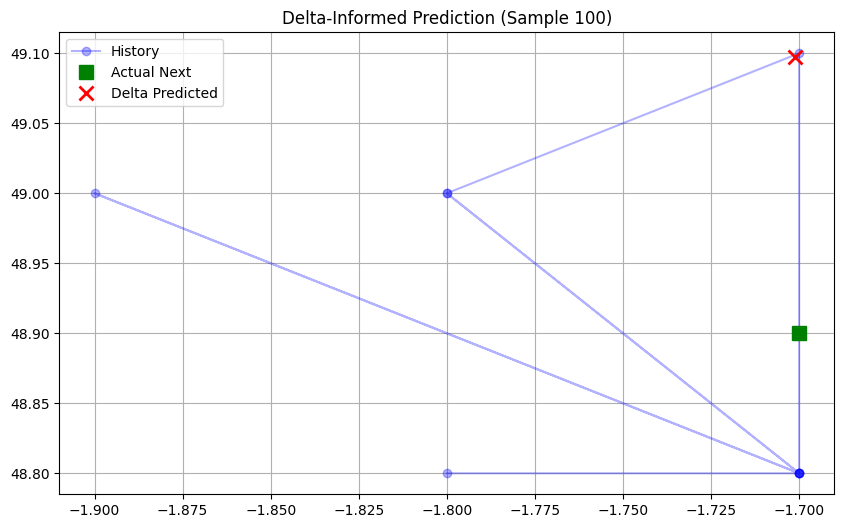

Reconstructed Distance Error: 21.9325 km


In [30]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_delta_prediction(model, dataset, sample_idx=0):
    model.eval()
    with torch.no_grad():
        sequence, delta_true, physics_ctx = dataset[sample_idx]
        
        # 1. Forward pass
        input_seq = sequence.unsqueeze(0).to(DEVICE)
        delta_pred = model(input_seq).cpu().numpy()[0]
        
        # 2. Get Last Known Position from the end of the sequence (unscaled)
        # Sequence shape is (window, features), features 0 and 1 are Lat/Lon
        last_scaled_pos = sequence[-1, :2].numpy()
        
        # 3. Reconstruct the Target Coordinate: Last Pos + Delta
        pred_scaled_coord = last_scaled_pos + delta_pred
        actual_scaled_coord = last_scaled_pos + delta_true.numpy()
        
        # 4. Inverse Scaling to real degrees
        lat_mean, lat_std = scaling_map['cell_ll_lat_mean'], scaling_map['cell_ll_lat_std']
        lon_mean, lon_std = scaling_map['cell_ll_lon_mean'], scaling_map['cell_ll_lon_std']
        
        pred_lat = (pred_scaled_coord[0] * lat_std) + lat_mean
        pred_lon = (pred_scaled_coord[1] * lon_std) + lon_mean
        actual_lat = (actual_scaled_coord[0] * lat_std) + lat_mean
        actual_lon = (actual_scaled_coord[1] * lon_std) + lon_mean
        
        # History for context
        hist_lat = (sequence[:, 0].numpy() * lat_std) + lat_mean
        hist_lon = (sequence[:, 1].numpy() * lon_std) + lon_mean

        # Plotting
        plt.figure(figsize=(10, 6))
        plt.plot(hist_lon, hist_lat, 'bo-', label="History", alpha=0.3)
        plt.plot(actual_lon, actual_lat, 'gs', markersize=10, label="Actual Next")
        plt.plot(pred_lon, pred_lat, 'rx', markersize=10, markeredgewidth=2, label="Delta Predicted")
        
        plt.title(f"Delta-Informed Prediction (Sample {sample_idx})")
        plt.legend()
        plt.grid(True)
        plt.show()
        
        error_km = np.sqrt((pred_lat - actual_lat)**2 + (pred_lon - actual_lon)**2) * 111
        print(f"Reconstructed Distance Error: {error_km:.4f} km")

visualize_delta_prediction(model, val_ds, sample_idx=100)

In [25]:
print(full_df.select(pl.col("delta_t")).describe())

shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ delta_t      │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 176369.0     │
│ null_count ┆ 0.0          │
│ mean       ┆ 95807.694096 │
│ std        ┆ 61040.29828  │
│ min        ┆ 86400.0      │
│ 25%        ┆ 86400.0      │
│ 50%        ┆ 86400.0      │
│ 75%        ┆ 86400.0      │
│ max        ┆ 2.3328e6     │
└────────────┴──────────────┘


In [31]:
# Calculate the 'Heading' change
full_df = full_df.with_columns([
    (pl.struct(["cell_ll_lat", "cell_ll_lon"])
       .map_batches(lambda x: np.degrees(np.arctan2(
           x.struct.field("cell_ll_lon").diff(), 
           x.struct.field("cell_ll_lat").diff()
       )))
       .alias("heading"))
])

print(full_df.select("heading").describe())

shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ heading     │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 176368.0    │
│ null_count ┆ 1.0         │
│ mean       ┆ 6.374973    │
│ std        ┆ 99.900216   │
│ min        ┆ -179.714884 │
│ 25%        ┆ -90.0       │
│ 50%        ┆ 0.0         │
│ 75%        ┆ 90.0        │
│ max        ┆ 180.0       │
└────────────┴─────────────┘
